# Conociendo mis Datos (EDA)

## Información del estudiante
Carlos A. Ramirez \[22212267]; L22212267@tectijuana.edu.mx

Introducción a las Ciencias de Datos

Ingeniería Biomédica

## Docente
Prof. Fortunato Ramirez Arzate

Departamento de Ingeniería Eléctrica y Electrónica, Tecnológico Nacional de México/IT Tijuana, Blvd. Alberto Limón Padilla s/n, Tijuana, C.P. 22454, B.C., México.

---

## 1. Objetivo

Que el estudiante sea capaz de:

* Cargar un dataset real en Python.
* Identificar y clasificar los tipos de atributos.
* Obtener descripciones estadísticas básicas.
* Visualizar datos numéricos y categóricos.
* Calcular medidas de similitud y disimilitud entre instancias.
* Interpretar los resultados obtenidos.

---

## 2. Introducción Teórica

Antes de aplicar modelos de Machine Learning, es necesario comprender la estructura y características del conjunto de datos. Esta etapa se denomina **Análisis Exploratorio de Datos (EDA, Exploratory Data Analysis)**.

El EDA permite:

* Detectar valores faltantes.
* Identificar tipos de atributos.
* Analizar distribuciones.
* Evaluar dispersión y variabilidad.
* Detectar valores atípicos.
* Medir similitud entre instancias.

### 2.1 Tipos de Atributos

* **Nominal:** Categorías sin orden (Ej. ocupación, país).
* **Binario:** Dos categorías posibles (Ej. sexo, ingreso >50K).
* **Ordinal:** Categorías con orden definido (Ej. nivel educativo si se jerarquiza).
* **Numérico:** Valores cuantitativos.

  * Discreto: valores enteros contables.
  * Continuo: mediciones con posibles decimales.

### 2.2 Medidas Estadísticas

**Tendencia central**

* Media
* Mediana
* Moda

**Dispersión**

* Rango
* Cuartiles
* IQR (Rango intercuartílico)
* Varianza
* Desviación estándar

### 2.3 Medidas de Similitud y Disimilitud

* Distancia Manhattan (p = 1)
* Distancia Euclidiana (p = 2)
* Distancia de Minkowski (generalización)
* Hamming (para binarios)
* Jaccard (para binarios)
* Similitud coseno
* Distancia para tipos mixtos (aproximación tipo Gower)

---

## 3. Material Necesario

* Computadora con Python instalado.
* Jupyter Notebook.
* Librerías:

  * numpy
  * pandas
  * matplotlib

Datasets recomendados:
https://archive.ics.uci.edu/datasets

---

## 4. Desarrollo de la Práctica

* Los pasos para el desarrollo de la Práctica se describen a continuación. Y en el archivo [Practica_Conociendo_tus_datos](Practica_Conociendo_tus_datos.ipynb) se desglosa a manera de ejemplo parte del procedimiento. Se recomienda realizar los pasos y el análisis para el dataset que se incluye y posteriormente elegir un dataset que ustedes deseen analizar.

---

# Parte I — Carga y Limpieza de Datos

## Paso 1: Importar librerías
En este paso, importamos las herramientas fundamentales para la manipulación de datos y visualización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Paso 2: Cargar el dataset
Definimos los nombres de las columnas basándonos en la documentación del archivo `wdbc.names`. Luego, leemos el archivo `.data` y visualizamos las primeras 5 filas para verificar que se haya cargado correctamente.

In [2]:
# Definir los nombres de las columnas basados en wdbc.names
columnas = [
    'id', 'diagnosis', 
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Leer el archivo CSV (wdbc.data no tiene encabezado propio)
df = pd.read_csv('wdbc.data', header=None, names=columnas)

# Mostrar las primeras 5 filas
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Paso 3: Limpieza
Aunque el dataset WDBC suele estar bastante limpio, por buenas prácticas revisaremos si existen valores faltantes representados por el carácter `?`. Los reemplazaremos por `NaN`, contaremos cuántos hay, y eliminaremos las filas afectadas mostrando el impacto en las dimensiones del dataset.

In [3]:
# Guardar las dimensiones originales antes de la limpieza
dimensiones_antes = df.shape

# 1. Reemplazar valores "?" por NaN
# Usamos regex=False para asegurar que busque exactamente el string "?"
df.replace('?', np.nan, inplace=True)

# 2. Contar valores faltantes por columna
valores_faltantes = df.isnull().sum()
print("Valores faltantes por columna:\n", valores_faltantes[valores_faltantes > 0]) # Solo mostramos las que tienen >0 para no saturar

# 3. Eliminar filas con valores faltantes
df.dropna(inplace=True)

# 4. Mostrar dimensiones antes y después
dimensiones_despues = df.shape

print("\n--- Resumen de Dimensiones ---")
print(f"Dimensiones antes de la limpieza: {dimensiones_antes}")
print(f"Dimensiones después de la limpieza: {dimensiones_despues}")

Valores faltantes por columna:
 Series([], dtype: int64)

--- Resumen de Dimensiones ---
Dimensiones antes de la limpieza: (569, 32)
Dimensiones después de la limpieza: (569, 32)


# Parte II — Identificación de Atributos

## Paso 4: Revisar tipos detectados por pandas
Antes de analizar los datos, es crucial entender cómo Python (a través de pandas) ha interpretado cada columna al momento de cargar el archivo. Utilizaremos `df.dtypes` y `df.nunique()` para registrar los tipos detectados y la cantidad de valores únicos.

In [4]:
# Mostrar el tipo de dato que pandas asignó a cada columna
print("Tipos de datos detectados por pandas:\n")
print(df.dtypes)

print("\n-----------------------------------\n")

# Contar el número de valores únicos por columna para ayudar en la clasificación
print("Número de valores únicos por columna:\n")
print(df.nunique())

Tipos de datos detectados por pandas:

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_wors

## Paso 5: Clasificación Teórica

A partir de los resultados de código anteriores y de la descripción original del dataset, podemos clasificar las variables según su naturaleza estadística. 

A continuación, se presenta la tabla resumen y la justificación teórica de las clasificaciones.

### Tabla de Clasificación de Atributos (Completa)

| Nombre del Atributo | Tipo Teórico | Tipo en Pandas | Número de Valores Únicos |
| :--- | :--- | :--- | :--- |
| `id` | Nominal (Identificador) | `int64` | 569 |
| `diagnosis` | Binario | `object` | 2 |
| `radius_mean` | Numérico (Continuo) | `float64` | 456 |
| `texture_mean` | Numérico (Continuo) | `float64` | 479 |
| `perimeter_mean` | Numérico (Continuo) | `float64` | 522 |
| `area_mean` | Numérico (Continuo) | `float64` | 539 |
| `smoothness_mean` | Numérico (Continuo) | `float64` | 474 |
| `compactness_mean` | Numérico (Continuo) | `float64` | 537 |
| `concavity_mean` | Numérico (Continuo) | `float64` | 537 |
| `concave_points_mean` | Numérico (Continuo) | `float64` | 542 |
| `symmetry_mean` | Numérico (Continuo) | `float64` | 432 |
| `fractal_dimension_mean` | Numérico (Continuo) | `float64` | 499 |
| `radius_se` | Numérico (Continuo) | `float64` | 540 |
| `texture_se` | Numérico (Continuo) | `float64` | 519 |
| `perimeter_se` | Numérico (Continuo) | `float64` | 533 |
| `area_se` | Numérico (Continuo) | `float64` | 528 |
| `smoothness_se` | Numérico (Continuo) | `float64` | 547 |
| `compactness_se` | Numérico (Continuo) | `float64` | 541 |
| `concavity_se` | Numérico (Continuo) | `float64` | 533 |
| `concave_points_se` | Numérico (Continuo) | `float64` | 507 |
| `symmetry_se` | Numérico (Continuo) | `float64` | 498 |
| `fractal_dimension_se` | Numérico (Continuo) | `float64` | 545 |
| `radius_worst` | Numérico (Continuo) | `float64` | 457 |
| `texture_worst` | Numérico (Continuo) | `float64` | 511 |
| `perimeter_worst` | Numérico (Continuo) | `float64` | 514 |
| `area_worst` | Numérico (Continuo) | `float64` | 544 |
| `smoothness_worst` | Numérico (Continuo) | `float64` | 411 |
| `compactness_worst` | Numérico (Continuo) | `float64` | 529 |
| `concavity_worst` | Numérico (Continuo) | `float64` | 539 |
| `concave_points_worst` | Numérico (Continuo) | `float64` | 492 |
| `symmetry_worst` | Numérico (Continuo) | `float64` | 500 |
| `fractal_dimension_worst`| Numérico (Continuo) | `float64` | 535 |

---

### Justificación de Clasificaciones

1. **`id` (Número de identificación):** Es de tipo **Nominal**. Aunque pandas lo detecta como un número entero (`int64`), teóricamente no tiene sentido realizar operaciones matemáticas con él (sumar dos IDs no da un nuevo paciente). Solo sirve como etiqueta única.
2. **`diagnosis` (Diagnóstico):** Es de tipo **Binario** (o Categórico Nominal dicotómico). Solo admite dos estados mutuamente excluyentes: "M" (Maligno) y "B" (Benigno). Pandas lo clasifica correctamente como `object`.
3. **`radius_mean` (Radio medio):** Es de tipo **Numérico Continuo**. Representa la media de las distancias desde el centro a los puntos del perímetro del núcleo. Es una medida física que puede tomar teóricamente cualquier valor dentro de un rango y contiene decimales (`float64`).
4. **`texture_mean` (Textura media):** Es de tipo **Numérico Continuo**. Representa la desviación estándar de los valores de escala de grises. Es un cálculo estadístico sobre píxeles que da como resultado un valor numérico continuo.
5. **`concave_points_mean` (Puntos cóncavos medios):** Es de tipo **Numérico Continuo**. Aunque el conteo original de puntos cóncavos podría ser un número entero (discreto), al calcular la "media" sobre varios núcleos en la imagen, el resultado se vuelve una proporción continua, justificada por su tipo `float64`.

# Parte III — Estadística Descriptiva

## Paso 6: Estadística general
Utilizamos el método `describe()` para obtener un resumen estadístico rápido (conteo, media, desviación estándar, mínimos, máximos y cuartiles) de las 30 características numéricas de los núcleos celulares.

In [5]:
# Mostrar la estadística general del dataframe
# Usamos .T (transpuesta) para que las 30 filas se lean mejor hacia abajo
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


## Paso 7: Tendencia Central
Calcularemos las medidas de tendencia central (media, mediana y moda) para las variables `radius_mean` (tamaño promedio del tumor) y `texture_mean` (variación en la escala de grises de la imagen) para entender dónde se concentran los valores típicos de las células analizadas.

In [6]:
# Definir las variables de interés para el estudio de cáncer de mama
variables = ['radius_mean', 'texture_mean']

# Calcular e imprimir las métricas para cada variable
for var in variables:
    media = df[var].mean()
    mediana = df[var].median()
    # mode() devuelve una serie, tomamos el primer valor [0] por si hay multimoda
    moda = df[var].mode()[0] 
    
    print(f"--- Estadísticas para: {var} ---")
    print(f"Media:   {media:.4f}")
    print(f"Mediana: {mediana:.4f}")
    print(f"Moda:    {moda:.4f}\n")

--- Estadísticas para: radius_mean ---
Media:   14.1273
Mediana: 13.3700
Moda:    12.3400

--- Estadísticas para: texture_mean ---
Media:   19.2896
Mediana: 18.8400
Moda:    14.9300



## Paso 8: Dispersión
Analizaremos qué tan esparcidos están los datos respecto a su centro para la variable `radius_mean`. Calcularemos el rango, los cuartiles, el rango intercuartílico (IQR), la varianza y la desviación estándar.

In [7]:
# Variable de interés principal
var = 'radius_mean'
data = df[var]

# Cálculos de dispersión
rango = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
varianza = data.var()
desv_est = data.std()

# Mostrar resultados
print(f"--- Medidas de Dispersión para: {var} ---")
print(f"Rango: {rango:.4f}")
print(f"Q1 (Percentil 25): {q1:.4f}")
print(f"Q3 (Percentil 75): {q3:.4f}")
print(f"Rango Intercuartílico (IQR): {iqr:.4f}")
print(f"Varianza: {varianza:.4f}")
print(f"Desviación Estándar: {desv_est:.4f}")

--- Medidas de Dispersión para: radius_mean ---
Rango: 21.1290
Q1 (Percentil 25): 11.7000
Q3 (Percentil 75): 15.7800
Rango Intercuartílico (IQR): 4.0800
Varianza: 12.4189
Desviación Estándar: 3.5240


### Interpretación Breve (`radius_mean`):
* **Rango e IQR:** El rango nos indica la diferencia total entre el núcleo celular más pequeño y el más grande registrados. El **IQR** nos muestra que el 50% central de los tumores tiene una variación de tamaño de apenas ~4 unidades, lo que nos ayuda a identificar si hay tumores con tamaños atípicos (outliers).
* **Varianza y Desviación Estándar:** La desviación estándar (~3.52) nos dice cuánto se desvía, en promedio, el radio de una célula respecto a la media general. Una desviación alta en estudios oncológicos suele indicar la presencia de masas tumorales malignas que crecen de forma irregular frente a las benignas que suelen ser más uniformes.

## Paso 9: Frecuencias en categóricas
El dataset WDBC contiene una única variable categórica: `diagnosis` (M = Maligno, B = Benigno). Analizaremos su frecuencia para conocer la proporción de clases en nuestro estudio.

In [8]:
print("--- Frecuencia de Diagnósticos ---")
# Mostrar el conteo de la variable categórica
frecuencias = df['diagnosis'].value_counts()
display(frecuencias)

# Opcional: Mostrarlo en porcentaje para mayor claridad
print("\n--- Proporción (%) ---")
display(df['diagnosis'].value_counts(normalize=True) * 100)

--- Frecuencia de Diagnósticos ---


diagnosis
B    357
M    212
Name: count, dtype: int64


--- Proporción (%) ---


diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

# Parte IV — Visualización de Datos

## Paso 10: Histogramas
Los histogramas nos ayudan a ver cómo se distribuyen las frecuencias de una variable continua. Generaremos un histograma para `radius_mean` (radio medio del núcleo celular) para observar la distribución de los tamaños tumorales.

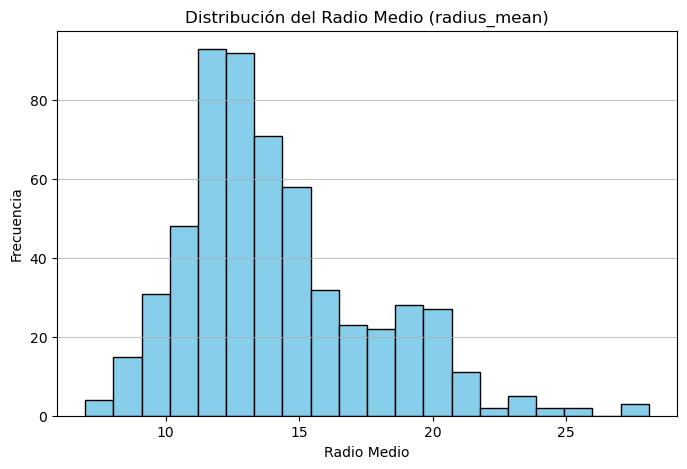

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['radius_mean'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución del Radio Medio (radius_mean)')
plt.xlabel('Radio Medio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Paso 11: Densidad (KDE)
La gráfica de densidad por estimación de densidad de kernel (KDE) es una versión suavizada del histograma. Graficaremos la densidad de `texture_mean` (textura media) para ver la forma de su distribución sin la restricción de los "bins" (barras) del histograma.

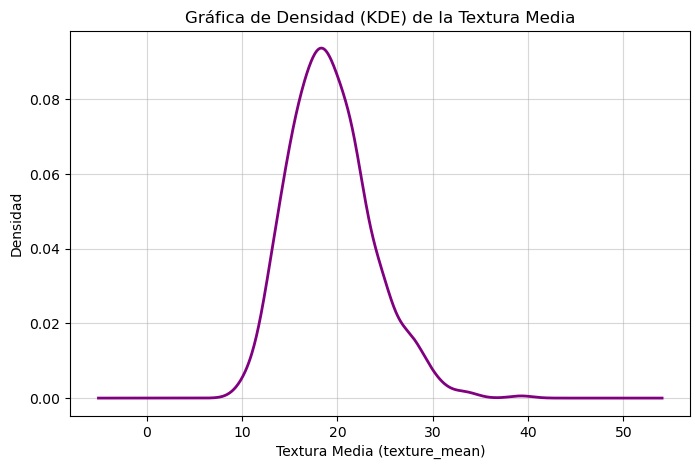

In [10]:
plt.figure(figsize=(8, 5))
df['texture_mean'].plot(kind='kde', color='purple', linewidth=2)
plt.title('Gráfica de Densidad (KDE) de la Textura Media')
plt.xlabel('Textura Media (texture_mean)')
plt.ylabel('Densidad')
plt.grid(alpha=0.5)
plt.show()

## Paso 12: Boxplot (Diagramas de Caja)

Los diagramas de caja son excelentes para identificar valores atípicos (outliers) y ver la dispersión de los datos basada en cuartiles. Graficaremos `radius_mean`, `texture_mean` y `perimeter_mean`. 

*Nota: Como tienen escalas diferentes, los graficaremos en subgráficos separados para apreciarlos correctamente.*

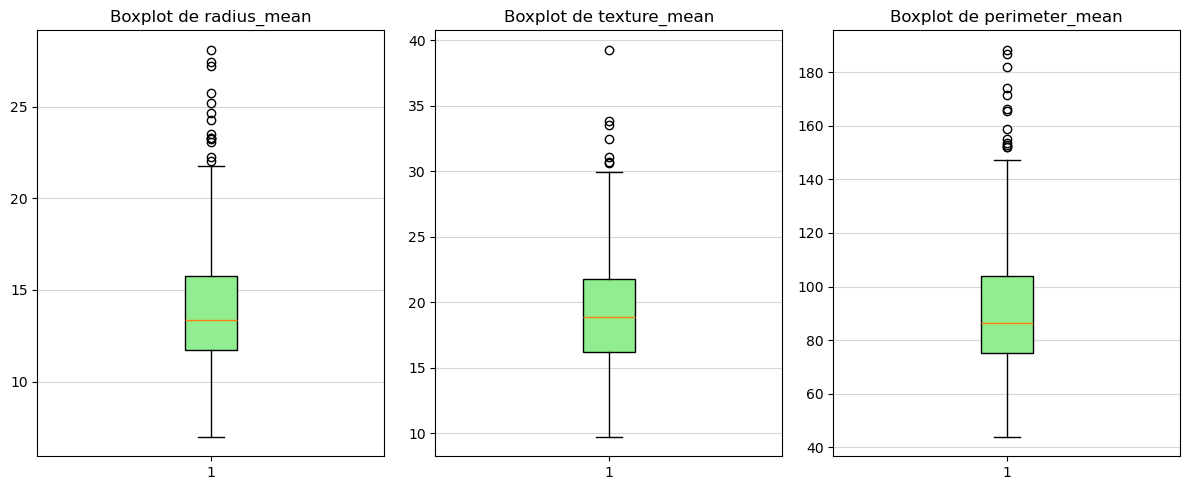

In [11]:
# Variables a graficar
vars_boxplot = ['radius_mean', 'texture_mean', 'perimeter_mean']

plt.figure(figsize=(12, 5))

for i, var in enumerate(vars_boxplot, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df[var], vert=True, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
    plt.title(f'Boxplot de {var}')
    plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

### Identificación de valores atípicos:
Al observar los boxplots, los puntos o círculos que aparecen por encima de la "línea" superior (el bigote superior) representan **valores atípicos**. En el contexto del cáncer de mama, estos valores inusualmente altos en radio, textura y perímetro suelen corresponder a células con núcleos anormalmente grandes o irregulares, lo cual es una fuerte característica de los tumores **malignos**.

## Paso 13: Scatter Plot (Gráfico de Dispersión)
Graficaremos `radius_mean` (radio) contra `texture_mean` (textura) para explorar si a medida que aumenta el tamaño de la célula, también cambia su textura.

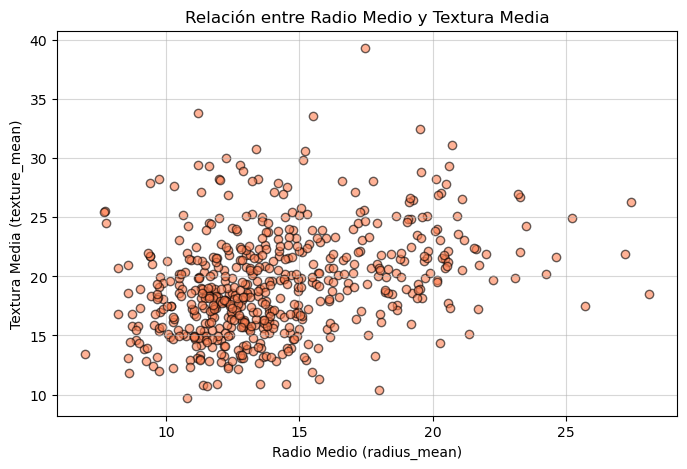

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df['radius_mean'], df['texture_mean'], alpha=0.6, color='coral', edgecolor='k')
plt.title('Relación entre Radio Medio y Textura Media')
plt.xlabel('Radio Medio (radius_mean)')
plt.ylabel('Textura Media (texture_mean)')
plt.grid(alpha=0.5)
plt.show()

### Interpretación:
Aunque se puede observar una ligera tendencia a que los núcleos más grandes (mayor radio) también presenten una mayor variación en la escala de grises (mayor textura), la relación lineal no es perfecta ni estrictamente fuerte. Sin embargo, la dispersión muestra que los valores altos en ambas métricas simultáneamente son menos comunes y podrían agruparse en una clasificación específica (probablemente tumores malignos).

## Paso 14: Gráfica de Barras
Utilizaremos la gráfica de barras para visualizar la frecuencia de nuestra variable categórica objetivo: `diagnosis`.

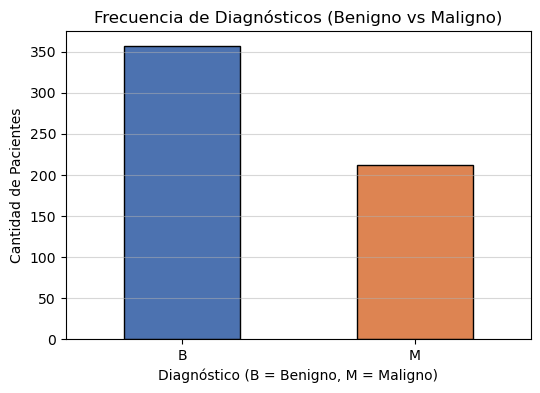

In [13]:
plt.figure(figsize=(6, 4))
# Contar valores y graficar
conteo_diagnostico = df['diagnosis'].value_counts()
conteo_diagnostico.plot(kind='bar', color=['#4C72B0', '#DD8452'], edgecolor='black')

plt.title('Frecuencia de Diagnósticos (Benigno vs Maligno)')
plt.xlabel('Diagnóstico (B = Benigno, M = Maligno)')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(rotation=0) # Para que las letras B y M queden derechas
plt.grid(axis='y', alpha=0.5)
plt.show()

# Parte V — Medición de Similitud y Disimilitud

## Paso 15: Selección de muestra
Para poder visualizar las matrices de distancias de manera clara, trabajaremos con una submuestra aleatoria de 10 pacientes (filas). Usaremos `random_state` para que los resultados sean reproducibles.

In [14]:
# Seleccionar una muestra de 10 filas y reiniciar el índice
df_muestra = df.sample(10, random_state=42).reset_index(drop=True)
display(df_muestra.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,87930,B,12.47,18.60,81.09,481.9,0.09965,0.1058,0.08005,0.03821,...,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750
1,859575,M,18.94,21.31,123.60,1130.0,0.09009,0.1029,0.10800,0.07951,...,24.86,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589
2,8670,M,15.46,19.48,101.70,748.9,0.10920,0.1223,0.14660,0.08087,...,19.26,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019
3,907915,B,12.40,17.68,81.47,467.8,0.10540,0.1316,0.07741,0.02799,...,12.88,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359
4,921385,B,11.54,14.44,74.65,402.9,0.09984,0.1120,0.06737,0.02594,...,12.26,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134


## 5.1 Distancias Numéricas
Seleccionaremos tres variables numéricas clave de nuestro estudio: `radius_mean` (radio), `texture_mean` (textura) y `perimeter_mean` (perímetro).

### Paso 16: Implementar función Minkowski

La distancia de Minkowski es una métrica generalizada. Cuando $p=1$ obtenemos la distancia Manhattan, y con $p=2$ obtenemos la distancia Euclidiana. Calcularemos ambas entre el paciente 0 y el paciente 1 de nuestra muestra.

In [15]:
# Seleccionar variables numéricas
vars_num = ['radius_mean', 'texture_mean', 'perimeter_mean']
datos_num = df_muestra[vars_num].values

# Función de Distancia Minkowski
def minkowski_dist(x, y, p):
    return np.sum(np.abs(x - y)**p)**(1/p)

paciente_0 = datos_num[0]
paciente_1 = datos_num[1]

dist_manhattan = minkowski_dist(paciente_0, paciente_1, p=1)
dist_euclidiana = minkowski_dist(paciente_0, paciente_1, p=2)

print(f"Distancia Manhattan (p=1) entre paciente 0 y 1: {dist_manhattan:.4f}")
print(f"Distancia Euclidiana (p=2) entre paciente 0 y 1: {dist_euclidiana:.4f}")

Distancia Manhattan (p=1) entre paciente 0 y 1: 51.6900
Distancia Euclidiana (p=2) entre paciente 0 y 1: 43.0849


### Paso 17: Matriz de Distancias
Construiremos una matriz de 10x10 que contenga la distancia Euclidiana ($p=2$) entre todos los pares de pacientes de nuestra muestra.

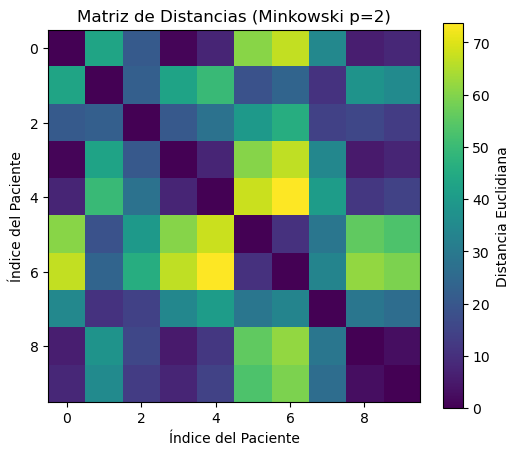

In [16]:
n = len(df_muestra)
matriz_distancias = np.zeros((n, n))

# Calcular la distancia euclidiana para cada par de pacientes
for i in range(n):
    for j in range(n):
        matriz_distancias[i, j] = minkowski_dist(datos_num[i], datos_num[j], p=2)

# Visualizar la matriz
plt.figure(figsize=(6, 5))
plt.imshow(matriz_distancias, cmap='viridis')
plt.colorbar(label='Distancia Euclidiana')
plt.title('Matriz de Distancias (Minkowski p=2)')
plt.xlabel('Índice del Paciente')
plt.ylabel('Índice del Paciente')
plt.show()

## 5.2 Distancias para Binarios
Como el dataset solo tiene una variable categórica (`diagnosis`), la convertiremos a binaria (M=1, B=0). Para enriquecer el ejercicio de similitud, crearemos una segunda variable binaria `is_large_tumor` que valdrá 1 si el radio supera la media global, y 0 en caso contrario.

### Paso 18 y 19: Implementar Hamming y Jaccard
Calcularemos estas métricas entre los vectores binarios de los pacientes 0 y 1.

In [17]:
# Crear dataframe temporal con variables binarias
df_bin = pd.DataFrame()
df_bin['diagnosis_bin'] = df_muestra['diagnosis'].map({'M': 1, 'B': 0})
df_bin['is_large_tumor'] = (df_muestra['radius_mean'] > df['radius_mean'].mean()).astype(int)

vec_0 = df_bin.iloc[0].values
vec_1 = df_bin.iloc[1].values

# Paso 18: Distancia Hamming (proporción de diferencias)
def hamming_dist(x, y):
    return np.sum(x != y) / len(x)

# Paso 19: Similitud Jaccard (intersección de 1s sobre unión de 1s)
def jaccard_sim(x, y):
    interseccion = np.sum((x == 1) & (y == 1))
    union = np.sum((x == 1) | (y == 1))
    return interseccion / union if union != 0 else 0.0

print(f"Vector binario Paciente 0: {vec_0}")
print(f"Vector binario Paciente 1: {vec_1}\n")
print(f"Distancia Hamming: {hamming_dist(vec_0, vec_1):.2f}")
print(f"Similitud Jaccard: {jaccard_sim(vec_0, vec_1):.2f}")

Vector binario Paciente 0: [0 0]
Vector binario Paciente 1: [1 1]

Distancia Hamming: 1.00
Similitud Jaccard: 0.00


## 5.3 Similitud Coseno

A diferencia de la distancia euclidiana, la similitud coseno mide el ángulo entre dos vectores, lo cual es útil para evaluar similitud de "perfiles" independientemente de la magnitud escalar. Primero, estandarizaremos las variables con $Z-score$.

### Paso 20: Implementar función de coseno y Matriz

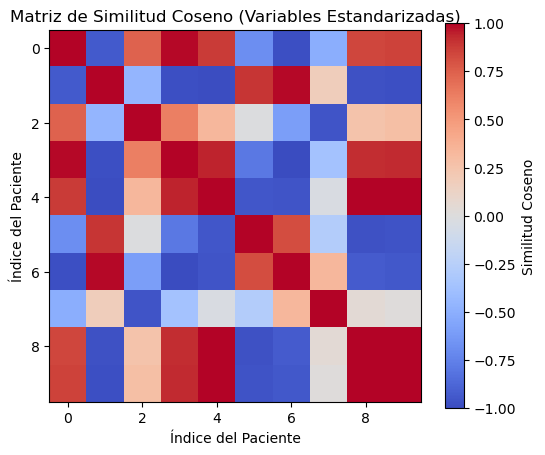

In [18]:
# Estandarizar usando Z-score: (X - media) / desv_est
datos_z = (datos_num - datos_num.mean(axis=0)) / datos_num.std(axis=0)

# Implementar Similitud Coseno
def similitud_coseno(x, y):
    dot_product = np.dot(x, y)
    norm_x = np.linalg.norm(x)
    norm_y = np.linalg.norm(y)
    return dot_product / (norm_x * norm_y)

matriz_coseno = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matriz_coseno[i, j] = similitud_coseno(datos_z[i], datos_z[j])

# Visualizar con mapa de calor
plt.figure(figsize=(6, 5))
plt.imshow(matriz_coseno, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Similitud Coseno')
plt.title('Matriz de Similitud Coseno (Variables Estandarizadas)')
plt.xlabel('Índice del Paciente')
plt.ylabel('Índice del Paciente')
plt.show()

## 5.4 Distancia para Tipos Mixtos
Para combinar variables numéricas (`radius_mean`, `texture_mean`) y categóricas (`diagnosis`), implementaremos una versión simplificada de la métrica de Gower:
1. Las numéricas se normalizan por su rango (diferencia absoluta dividida por max-min).
2. Las categóricas se evalúan: 0 si son iguales, 1 si son diferentes.
3. Se promedian todas las distancias.

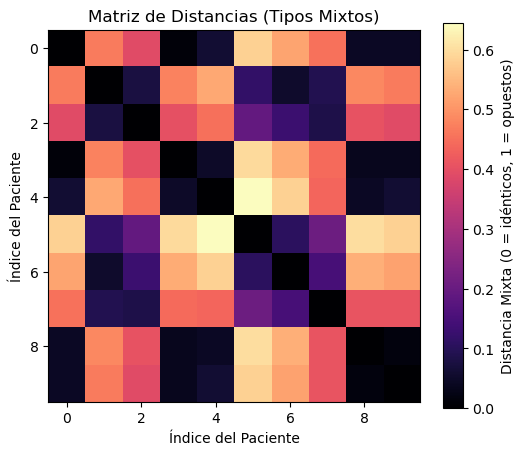

In [19]:
# Obtener rangos del dataset original para normalizar
rango_radius = df['radius_mean'].max() - df['radius_mean'].min()
rango_texture = df['texture_mean'].max() - df['texture_mean'].min()

matriz_mixta = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        # Distancias normalizadas numéricas
        dist_rad = abs(df_muestra['radius_mean'].iloc[i] - df_muestra['radius_mean'].iloc[j]) / rango_radius
        dist_tex = abs(df_muestra['texture_mean'].iloc[i] - df_muestra['texture_mean'].iloc[j]) / rango_texture
        
        # Distancia categórica
        cat_i = df_muestra['diagnosis'].iloc[i]
        cat_j = df_muestra['diagnosis'].iloc[j]
        dist_cat = 0 if cat_i == cat_j else 1
        
        # Promedio final
        distancia_total = (dist_rad + dist_tex + dist_cat) / 3.0
        matriz_mixta[i, j] = distancia_total

# Visualizar matriz
plt.figure(figsize=(6, 5))
plt.imshow(matriz_mixta, cmap='magma')
plt.colorbar(label='Distancia Mixta (0 = idénticos, 1 = opuestos)')
plt.title('Matriz de Distancias (Tipos Mixtos)')
plt.xlabel('Índice del Paciente')
plt.ylabel('Índice del Paciente')
plt.show()